In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import torch
from ncpu.runner  import TrainRunnerUI, setup_trainer
from ncpu.config import BIG_CONJUNCTION_TRAINING_CONFIG, TINY_CONJUNCTION_TRAINING_CONFIG
import mediapy as media

In [2]:
# TrainRunnerUI(BIG_CONJUNCTION_TRAINING_CONFIG).render()

In [3]:
trainer = setup_trainer(TINY_CONJUNCTION_TRAINING_CONFIG)

Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([16, 32, 32]) -> torch.Size([16, 32, 32])
  first_state: torch.Size([16, 16, 32, 32])
  rollout: torch.Size([16, 11, 16, 32, 32])
  loss: 0.035400390625
Sanity check completed successfully


In [4]:
# state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
# trainer.nca.load_state_dict(state_dict)

loss=0.010958:   0%|          | 750/200000 [02:02<8:05:13,  6.84it/s]

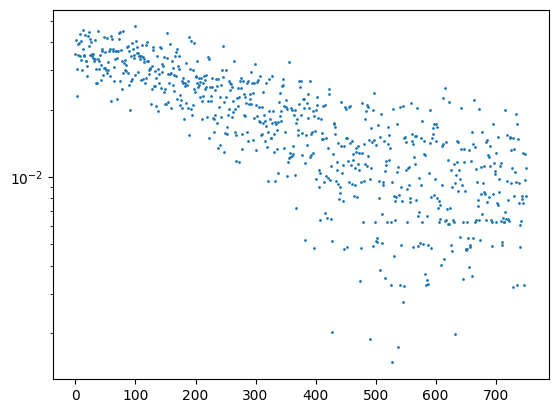

inp    : (16, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.06, std=0.24
out    : (16, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.02, std=0.14
nca_out: (16, 32, 32) torch.float32, min=-0.57, max=0.31, mean=-0.00, std=0.04


,,,,,,,
,,,,,,,
,,,,,,,

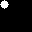
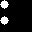
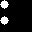
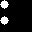
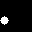
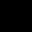
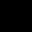
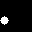
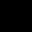
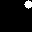
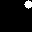
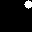
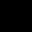
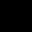
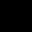
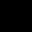
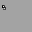
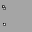
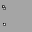
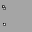
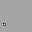
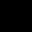
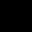
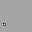

#0,#1,#2,#3,#4,#5,#6,#7

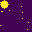
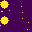
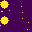
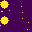
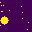
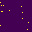
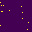
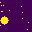

In [ ]:
from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime
from ncpu.utils import print_tensor, sequence_batch_to_html_gifs

pbar = tqdm(range(200_000))
for i in pbar:
    info = trainer.optim_step()
    loss = info["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 250 == 0:
        clear_output(wait=False)
        display(pbar.container)
        plt.scatter(range(len(trainer.history)), trainer.history, s=1)
        plt.yscale("log")
        plt.show()

        print_tensor("inp    ", info["inp"])
        print_tensor("out    ", info["out"])
        print_tensor("nca_out", info["nca_out"])

        to_show = 8
        inp = info["inp"][:to_show]
        out = info["out"][:to_show]
        nca_out = info["nca_out"][:to_show]
        rollout = info["rollout"][:to_show]
        io = torch.cat([inp, out, nca_out], dim=0)

        media.show_images(io.detach().cpu(), columns=to_show, width=100, height=100)
        sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

        it = len(trainer.history)

        checkpoint_dir = "checkpoints"
        if not os.path.isdir(checkpoint_dir):
            os.makedirs(checkpoint_dir, exist_ok=True)
        path = f"{checkpoint_dir}/ncpu_{it}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(trainer.nca.state_dict(), path)